# agentv21_official_a2a_sdk

This notebook uses the official `a2a-sdk`.

Start the official A2A server first:

```bash
python -m agentv21_official_a2a_sdk.official_a2a_server
```


In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

BASE_URL = "http://127.0.0.1:8401"

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("Official A2A server:", BASE_URL)


OpenAI API key present: True
Official A2A server: http://127.0.0.1:8401


## Install dependencies


In [2]:
# Optional: uncomment in a fresh environment.
# %pip install -U "a2a-sdk[http-server]" langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter httpx uvicorn starlette


## Official A2A imports


In [3]:
import asyncio
import httpx

from a2a.client import A2ACardResolver, ClientConfig, create_client
from a2a.helpers import display_agent_card, new_text_message
from a2a.types.a2a_pb2 import GetExtendedAgentCardRequest, Role, SendMessageRequest


## Fetch public Agent Card


In [4]:
async with httpx.AsyncClient() as httpx_client:
    resolver = A2ACardResolver(httpx_client=httpx_client, base_url=BASE_URL)
    public_agent_card = await resolver.get_agent_card()

display_agent_card(public_agent_card)


                     AgentCard                      
--- General ---
Name        : Official A2A EPP Incident Agent
Description : EPP SLA incident analysis agent implemented with the official A2A Python SDK.
Version     : 0.1.0

--- Interfaces ---
  [0] http://127.0.0.1:8401  (JSONRPC)

--- Capabilities ---
Streaming           : True
Push notifications  : False
Extended agent card : True

--- I/O Modes ---
Input  : text/plain
Output : text/plain

--- Skills ---
----------------------------------------------------
  ID          : epp_incident_analysis
  Name        : EPP Incident Analysis
  Description : Analyzes EPP SLA incidents, timeout spikes, release impact, latency symptoms, and failure concentration.
  Tags        : a2a, epp, incident-analysis
  Example     : Investigate CHECK-DOMAIN timeout spike after R13
  Example     : Analyze EPP latency after latest release


## Send non-streaming official A2A message


In [5]:
config = ClientConfig(streaming=False)
client = await create_client(agent=public_agent_card, client_config=config)

message = new_text_message(
    "Investigate CHECK-DOMAIN timeout spike after R13.",
    role=Role.ROLE_USER,
)
request = SendMessageRequest(message=message)

non_streaming_chunks = []
async for chunk in client.send_message(request):
    print(chunk)
    non_streaming_chunks.append(str(chunk))

await client.close()


task {
  id: "30c7817d-e16a-4f77-b467-e22b26a1f392"
  context_id: "7cecf6d7-2fd6-459e-ad25-a506073e934b"
  status {
    state: TASK_STATE_COMPLETED
    message {
      message_id: "52fdef62-6bd6-4d53-9a96-477282e92579"
      role: ROLE_AGENT
      parts {
        text: "EPP incident analysis completed."
      }
    }
    timestamp {
      seconds: 1782595483
      nanos: 292017000
    }
  }
  artifacts {
    artifact_id: "9c9e14e7-ac16-4074-954d-7b7ef29c63fb"
    parts {
      text: "Official A2A SDK Agent Response: For CHECK-DOMAIN timeout spikes after R13, likely causes include upstream registry connectivity degradation, DNS resolver latency, or connection pool saturation. Recommended next actions: inspect registry endpoint health, compare pre/post-release failure volume, check p95 response_time, and validate CONNECTION_TIMEOUT concentration by client. Original request: Investigate CHECK-DOMAIN timeout spike after R13."
      media_type: "text/plain"
    }
  }
  history {
    message

## Send streaming official A2A message


In [6]:
streaming_config = ClientConfig(streaming=True)
streaming_client = await create_client(agent=public_agent_card, client_config=streaming_config)

message = new_text_message(
    "Investigate CHECK-DOMAIN timeout spike after R13.",
    role=Role.ROLE_USER,
)
request = SendMessageRequest(message=message)

streaming_chunks = []
async for chunk in streaming_client.send_message(request):
    print(chunk)
    streaming_chunks.append(str(chunk))

await streaming_client.close()


task {
  id: "c701bf0d-567b-4f30-9ebf-ecd0cf75d4d0"
  context_id: "1c089c97-7c6c-4fbd-944e-e178b466236d"
  status {
    state: TASK_STATE_SUBMITTED
  }
  history {
    message_id: "a0aba697-2784-41ef-8123-fc7312364c6c"
    context_id: "1c089c97-7c6c-4fbd-944e-e178b466236d"
    task_id: "c701bf0d-567b-4f30-9ebf-ecd0cf75d4d0"
    role: ROLE_USER
    parts {
      text: "Investigate CHECK-DOMAIN timeout spike after R13."
    }
  }
}

status_update {
  task_id: "c701bf0d-567b-4f30-9ebf-ecd0cf75d4d0"
  context_id: "1c089c97-7c6c-4fbd-944e-e178b466236d"
  status {
    state: TASK_STATE_WORKING
    message {
      message_id: "df21dc73-6208-4cf2-80d8-1a174e09af9a"
      role: ROLE_AGENT
      parts {
        text: "Processing EPP incident request..."
      }
    }
    timestamp {
      seconds: 1782595773
      nanos: 554593000
    }
  }
}

artifact_update {
  task_id: "c701bf0d-567b-4f30-9ebf-ecd0cf75d4d0"
  context_id: "1c089c97-7c6c-4fbd-944e-e178b466236d"
  artifact {
    artifact_id: "a9

## Fetch extended Agent Card


In [7]:
extended_client = await create_client(
    agent=public_agent_card,
    client_config=ClientConfig(streaming=False),
)

extended_card = await extended_client.get_extended_agent_card(
    GetExtendedAgentCardRequest()
)

display_agent_card(extended_card)
await extended_client.close()


                     AgentCard                      
--- General ---
Name        : Official A2A EPP Incident Agent - Extended
Description : Extended card with additional debug skill.
Version     : 0.1.0

--- Interfaces ---
  [0] http://127.0.0.1:8401  (JSONRPC)

--- Capabilities ---
Streaming           : True
Push notifications  : False
Extended agent card : True

--- I/O Modes ---
Input  : text/plain
Output : text/plain

--- Skills ---
----------------------------------------------------
  ID          : epp_incident_analysis
  Name        : EPP Incident Analysis
  Description : Analyzes EPP SLA incidents, timeout spikes, release impact, latency symptoms, and failure concentration.
  Tags        : a2a, epp, incident-analysis
  Example     : Investigate CHECK-DOMAIN timeout spike after R13
  Example     : Analyze EPP latency after latest release
----------------------------------------------------
  ID          : epp_incident_analysis_debug
  Name        : EPP Incident Analysis Debug
  

## LangGraph host state and nodes


In [8]:
from typing import NotRequired, TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph

class AgentState(TypedDict):
    input: str
    agent_card_text: NotRequired[str]
    a2a_chunks: NotRequired[list[str]]
    final_answer: NotRequired[str]

async def discover_agent_node(state: AgentState) -> AgentState:
    async with httpx.AsyncClient() as httpx_client:
        resolver = A2ACardResolver(httpx_client=httpx_client, base_url=BASE_URL)
        card = await resolver.get_agent_card()
    return {"agent_card_text": str(card)}

async def call_a2a_agent_node(state: AgentState) -> AgentState:
    async with httpx.AsyncClient() as httpx_client:
        resolver = A2ACardResolver(httpx_client=httpx_client, base_url=BASE_URL)
        card = await resolver.get_agent_card()

    client = await create_client(agent=card, client_config=ClientConfig(streaming=True))
    message = new_text_message(state["input"], role=Role.ROLE_USER)
    request = SendMessageRequest(message=message)

    chunks = []
    async for chunk in client.send_message(request):
        print(chunk)
        chunks.append(str(chunk))

    await client.close()
    return {"a2a_chunks": chunks}

async def synthesize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    prompt = f'''
User request:
{state["input"]}

Discovered official A2A agent card:
{state["agent_card_text"]}

Official A2A response chunks:
{state["a2a_chunks"]}

Write a concise final answer summarizing the official A2A agent result.
'''
    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


## Build graph


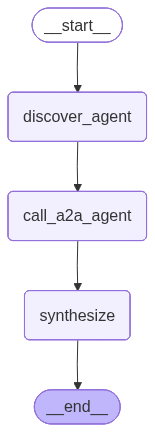

In [9]:
def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("discover_agent", discover_agent_node)
    graph_builder.add_node("call_a2a_agent", call_a2a_agent_node)
    graph_builder.add_node("synthesize", synthesize_node)

    graph_builder.add_edge(START, "discover_agent")
    graph_builder.add_edge("discover_agent", "call_a2a_agent")
    graph_builder.add_edge("call_a2a_agent", "synthesize")
    graph_builder.add_edge("synthesize", END)

    return graph_builder.compile()

graph = build_graph()
graph


## Visualize graph


In [10]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	discover_agent(discover_agent)
	call_a2a_agent(call_a2a_agent)
	synthesize(synthesize)
	__end__([<p>__end__</p>]):::last
	__start__ --> discover_agent;
	call_a2a_agent --> synthesize;
	discover_agent --> call_a2a_agent;
	synthesize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## Run LangGraph host


In [11]:
result = await graph.ainvoke({
    "input": "Investigate CHECK-DOMAIN timeout spike after R13."
})

print(result["final_answer"])


task {
  id: "ad8854fe-753c-4284-8bfd-92450949b82b"
  context_id: "82423b7b-ff78-4b54-88a2-3927fccbf26f"
  status {
    state: TASK_STATE_SUBMITTED
  }
  history {
    message_id: "69eb9749-07b2-47ae-9547-a8ffd3b5e105"
    context_id: "82423b7b-ff78-4b54-88a2-3927fccbf26f"
    task_id: "ad8854fe-753c-4284-8bfd-92450949b82b"
    role: ROLE_USER
    parts {
      text: "Investigate CHECK-DOMAIN timeout spike after R13."
    }
  }
}

status_update {
  task_id: "ad8854fe-753c-4284-8bfd-92450949b82b"
  context_id: "82423b7b-ff78-4b54-88a2-3927fccbf26f"
  status {
    state: TASK_STATE_WORKING
    message {
      message_id: "f00f450e-5f48-4fdf-880e-764e52d07be7"
      role: ROLE_AGENT
      parts {
        text: "Processing EPP incident request..."
      }
    }
    timestamp {
      seconds: 1782595895
      nanos: 691907000
    }
  }
}

artifact_update {
  task_id: "ad8854fe-753c-4284-8bfd-92450949b82b"
  context_id: "82423b7b-ff78-4b54-88a2-3927fccbf26f"
  artifact {
    artifact_id: "55

## Stream LangGraph host updates


In [12]:
async for chunk in graph.astream(
    {"input": "Investigate CHECK-DOMAIN timeout spike after R13."},
    stream_mode="updates",
):
    print("\n--- host update ---")
    print(chunk)



--- host update ---
{'discover_agent': {'agent_card_text': 'name: "Official A2A EPP Incident Agent"\ndescription: "EPP SLA incident analysis agent implemented with the official A2A Python SDK."\nsupported_interfaces {\n  url: "http://127.0.0.1:8401"\n  protocol_binding: "JSONRPC"\n}\nversion: "0.1.0"\ncapabilities {\n  streaming: true\n  extended_agent_card: true\n}\ndefault_input_modes: "text/plain"\ndefault_output_modes: "text/plain"\nskills {\n  id: "epp_incident_analysis"\n  name: "EPP Incident Analysis"\n  description: "Analyzes EPP SLA incidents, timeout spikes, release impact, latency symptoms, and failure concentration."\n  tags: "a2a"\n  tags: "epp"\n  tags: "incident-analysis"\n  examples: "Investigate CHECK-DOMAIN timeout spike after R13"\n  examples: "Analyze EPP latency after latest release"\n  input_modes: "text/plain"\n  output_modes: "text/plain"\n}\n'}}
task {
  id: "523b6b7f-43b2-41b8-87c4-a43f180279af"
  context_id: "59f31468-d4bf-4223-80c1-c77e103378ce"
  status {
